# 02 — Forward Propagation (Manual NumPy)

We trace one real MNIST image through a deliberately tiny **784 → 4 → 10** network so every intermediate quantity remains inspectable.


## Equations
$$z^{(1)}=xW^{(1)}+b^{(1)},\quad a^{(1)}=\operatorname{ReLU}(z^{(1)})$$
$$z^{(2)}=a^{(1)}W^{(2)}+b^{(2)},\quad \hat y=\operatorname{softmax}(z^{(2)})$$

A matrix multiplication is just many scalar multiply-add operations executed together.


train (5000, 784) test (1000, 784)


true 0
z1 [[-0.18186 -0.45604 -0.13504 -0.0817 ]]
a1 [[0. 0. 0. 0.]]
manual h0 -0.18186376789128733 matrix h0 -0.18186376789128733
p [[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]] pred 0


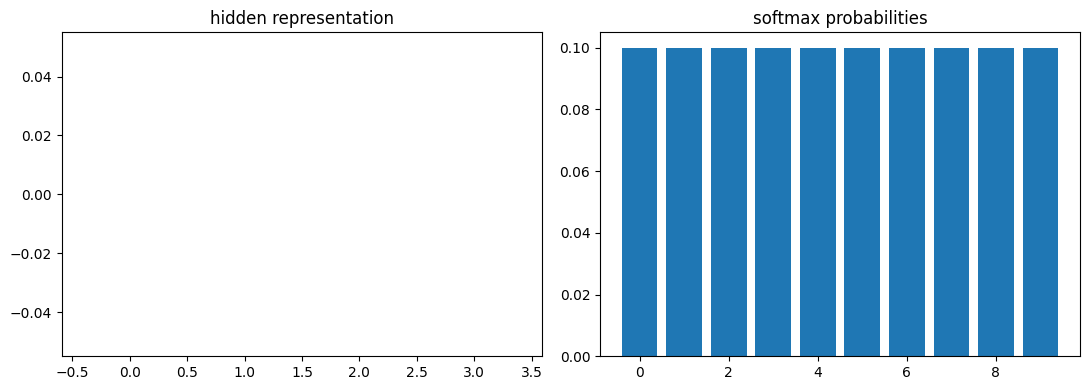

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import matplotlib.pyplot as plt
rng=np.random.default_rng(42);x=x_train[:1];y=int(y_train[0])
W1=rng.normal(0,.03,(784,4));b1=np.zeros((1,4));W2=rng.normal(0,.05,(4,10));b2=np.zeros((1,10))
z1=x@W1+b1;a1=np.maximum(z1,0);z2=a1@W2+b2;e=np.exp(z2-z2.max(1,keepdims=True));p=e/e.sum(1,keepdims=True)
manual=(x[0]*W1[:,0]).sum()+b1[0,0]
print('true',y);print('z1',z1.round(5));print('a1',a1.round(5));print('manual h0',manual,'matrix h0',z1[0,0]);print('p',p.round(5),'pred',int(p.argmax()))
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].bar(range(4),a1[0]);axes[0].set_title('hidden representation');axes[1].bar(range(10),p[0]);axes[1].set_title('softmax probabilities');plt.tight_layout();plt.show()


**Inference:** no learning happens during forward propagation. With fixed inputs and parameters, the prediction is deterministic. The hidden activation vector is the current learned representation of the image.
